# 06 Setup costs & machine allocation


- **Model A** : the notebook 05 baseline (continuous, no setup), rebuilt fresh here so the comparison against Model B is apples-to-apples within the same run, not against possibly-stale numbers from a previous notebook execution.
- **Model B** : adds the binary setup variable, setup time/cost, and `min_batch_size`.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pyomo.environ as pyo
import time

In [2]:
products = pd.read_csv('../data/optimization/products.csv')
machines = pd.read_csv('../data/optimization/machines.csv')
routing = pd.read_csv('../data/optimization/routing.csv')
materials = pd.read_csv('../data/optimization/materials.csv')
bills = pd.read_csv('../data/optimization/bill_of_materials.csv')
availability = pd.read_csv('../data/optimization/machine_availability.csv')
forecast = pd.read_csv('../data/processed/forecasts/forecast.csv')

## Reconcile week numbering

In [3]:
forecast_weeks = sorted(forecast["week"].unique())
week_to_t = {week: t for t, week in enumerate(forecast_weeks, start=1)}

forecast["t"] = forecast["week"].map(week_to_t)
availability["t"] = availability["week"]

assert forecast["t"].between(1, 12).all()
assert availability["t"].between(1, 12).all()

## Sets

In [4]:
P = products["product_id"].tolist()
M = machines["machine_id"].tolist()
T = sorted(forecast["t"].unique().tolist())
R = materials["material_id"].tolist()
PM = list(routing[["product_id", "machine_id"]].itertuples(index=False, name=None))

print(f"{len(P)} products, {len(M)} machines, {len(T)} periods, {len(R)} materials, {len(PM)} valid (product, machine) pairs")

10 products, 6 machines, 12 periods, 13 materials, 20 valid (product, machine) pairs


## Parameters

In [5]:
OVERTIME_WAGE_PER_HOUR = 35  # $ per operator-hour

overtime_cost_per_hour = {
    row.machine_id: OVERTIME_WAGE_PER_HOUR * row.labor_requirement
    for row in machines.itertuples()
}
overtime_hours = machines.set_index("machine_id")["overtime_hours"].to_dict()

availability_fraction = machines.set_index("machine_id")["availability"].to_dict()

available_hours = {
    (row.machine_id, row.t): row.available_hours * availability_fraction[row.machine_id]
    for row in availability.itertuples()
}

In [6]:
production_cost = products.set_index("product_id")["production_cost"].to_dict()
holding_cost = products.set_index("product_id")["holding_cost"].to_dict()
shortage_cost = products.set_index("product_id")["shortage_cost"].to_dict()
max_inventory = products.set_index("product_id")["max_inventory"].to_dict()
safety_stock = products.set_index("product_id")["safety_stock"].to_dict()
initial_inventory = products.set_index("product_id")["safety_stock"].to_dict()

demand = {(row.product_id, row.t): row.forecast for row in forecast.itertuples()}

In [7]:
processing_time = {(row.product_id, row.machine_id): row.processing_time for row in routing.itertuples()}

material_availability = materials.set_index("material_id")["availability"].to_dict()
material_qty = {(row.product_id, row.material_id): row.quantity_required for row in bills.itertuples()}

## New: setup parameters + BigM

`setup_time`, `setup_cost`, `min_batch_size` were already in `routing.csv` but unused until now. `BigM[p,m]` links the binary `y[p,m,t]` to `x[p,m,t]` : computed *tight* per pair (the most that machine could physically produce in its best week, fully loaded with overtime)
rather than one arbitrary large constant, since a loose BigM weakens the LP relaxation and can slow the solver down.

In [8]:
setup_time = {(row.product_id, row.machine_id): row.setup_time for row in routing.itertuples()}
setup_cost = {(row.product_id, row.machine_id): row.setup_cost for row in routing.itertuples()}
min_batch_size = {(row.product_id, row.machine_id): row.min_batch_size for row in routing.itertuples()}

available_hours_max = {m: max(available_hours[(m, t)] for t in T) for m in M}
BigM = {
    (p, m): (available_hours_max[m] + overtime_hours[m]) / processing_time[(p, m)]
    for (p, m) in PM
}

print("example setup_cost (P01, M01):", setup_cost[("P01", "M01")])
print("example min_batch_size (P01, M01):", min_batch_size[("P01", "M01")])
print("example BigM (P01, M01):", round(BigM[("P01", "M01")], 1))

example setup_cost (P01, M01): 60.0
example min_batch_size (P01, M01): 150
example BigM (P01, M01): 5265.0


## Shared constraint rules

Inventory balance, max-inventory, safety-stock, and material constraints are identical between Model A and Model B, written once here and applied to both model objects below (a Pyomo rule just receives whichever model instance owns the constraint as its first argument).

In [9]:
def inventory_balance_rule(model, p, t):
    prev_inv = initial_inventory[p] if t == T[0] else model.inv[p, t - 1]
    production = sum(model.x[p, m, t] for m in M if (p, m) in PM)
    return prev_inv + production == demand[p, t] - model.shortage[p, t] + model.inv[p, t]

def max_inventory_rule(model, p, t):
    return model.inv[p, t] <= max_inventory[p]

def safety_stock_rule(model, p, t):
    return model.inv[p, t] >= safety_stock[p]

def material_rule(model, r, t):
    used = sum(
        material_qty[p, r] * sum(model.x[p, m, t] for m in M if (p, m) in PM)
        for p in P if (p, r) in material_qty
    )
    return used <= material_availability[r]

## Model A : baseline (no setup), rebuilt fresh

In [10]:
model_a = pyo.ConcreteModel(name="baseline_no_setup")

model_a.P = pyo.Set(initialize=P)
model_a.M = pyo.Set(initialize=M)
model_a.T = pyo.Set(initialize=T)
model_a.R = pyo.Set(initialize=R)
model_a.PM = pyo.Set(initialize=PM, dimen=2)

model_a.x = pyo.Var(model_a.PM, model_a.T, domain=pyo.NonNegativeReals)
model_a.inv = pyo.Var(model_a.P, model_a.T, domain=pyo.NonNegativeReals)
model_a.shortage = pyo.Var(model_a.P, model_a.T, domain=pyo.NonNegativeReals)
model_a.overtime = pyo.Var(model_a.M, model_a.T, domain=pyo.NonNegativeReals,
                            bounds=lambda model, m, t: (0, overtime_hours[m]))

model_a.inventory_balance = pyo.Constraint(model_a.P, model_a.T, rule=inventory_balance_rule)
model_a.max_inventory_con = pyo.Constraint(model_a.P, model_a.T, rule=max_inventory_rule)
model_a.safety_stock_con = pyo.Constraint(model_a.P, model_a.T, rule=safety_stock_rule)
model_a.material_con = pyo.Constraint(model_a.R, model_a.T, rule=material_rule)

def machine_capacity_rule_a(model, m, t):
    used = sum(processing_time[p, m] * model.x[p, m, t] for p in P if (p, m) in PM)
    return used <= available_hours[m, t] + model.overtime[m, t]

model_a.machine_capacity = pyo.Constraint(model_a.M, model_a.T, rule=machine_capacity_rule_a)

def objective_rule_a(model):
    production_term = sum(production_cost[p] * model.x[p, m, t] for (p, m) in PM for t in T)
    holding_term = sum(holding_cost[p] * model.inv[p, t] for p in P for t in T)
    overtime_term = sum(overtime_cost_per_hour[m] * model.overtime[m, t] for m in M for t in T)
    shortage_term = sum(shortage_cost[p] * model.shortage[p, t] for p in P for t in T)
    return production_term + holding_term + overtime_term + shortage_term

model_a.objective = pyo.Objective(rule=objective_rule_a, sense=pyo.minimize)

solver = pyo.SolverFactory("appsi_highs")
results_a = solver.solve(model_a, tee=False)

print("Model A termination:", results_a.solver.termination_condition)
print("Model A total cost:", round(pyo.value(model_a.objective), 2))

Model A termination: optimal
Model A total cost: 72878.47


## Model B : setup costs, machine allocation, min batch size

New variable `y[p,m,t]` (binary: was product p produced on machine m in period t), the BigM linking constraints, `min_batch_size` enforcement, and `setup_time`/`setup_cost` added to the capacity constraint and objective.

In [11]:
model_b = pyo.ConcreteModel(name="setup_and_allocation")

model_b.P = pyo.Set(initialize=P)
model_b.M = pyo.Set(initialize=M)
model_b.T = pyo.Set(initialize=T)
model_b.R = pyo.Set(initialize=R)
model_b.PM = pyo.Set(initialize=PM, dimen=2)

model_b.x = pyo.Var(model_b.PM, model_b.T, domain=pyo.NonNegativeReals)
model_b.y = pyo.Var(model_b.PM, model_b.T, domain=pyo.Binary)
model_b.inv = pyo.Var(model_b.P, model_b.T, domain=pyo.NonNegativeReals)
model_b.shortage = pyo.Var(model_b.P, model_b.T, domain=pyo.NonNegativeReals)
model_b.overtime = pyo.Var(model_b.M, model_b.T, domain=pyo.NonNegativeReals,
                            bounds=lambda model, m, t: (0, overtime_hours[m]))

print("y has", len(model_b.y), "binary entries")

y has 240 binary entries


In [12]:
model_b.inventory_balance = pyo.Constraint(model_b.P, model_b.T, rule=inventory_balance_rule)
model_b.max_inventory_con = pyo.Constraint(model_b.P, model_b.T, rule=max_inventory_rule)
model_b.safety_stock_con = pyo.Constraint(model_b.P, model_b.T, rule=safety_stock_rule)
model_b.material_con = pyo.Constraint(model_b.R, model_b.T, rule=material_rule)

# Machine capacity: processing time AND setup time both consume the same hours budget
def machine_capacity_rule_b(model, m, t):
    used = sum(
        processing_time[p, m] * model.x[p, m, t] + setup_time[p, m] * model.y[p, m, t]
        for p in P if (p, m) in PM
    )
    return used <= available_hours[m, t] + model.overtime[m, t]

model_b.machine_capacity = pyo.Constraint(model_b.M, model_b.T, rule=machine_capacity_rule_b)

# Linking: can't produce without activating the setup (tight per-pair BigM)
def link_upper_rule(model, p, m, t):
    return model.x[p, m, t] <= BigM[p, m] * model.y[p, m, t]

model_b.link_upper = pyo.Constraint(model_b.PM, model_b.T, rule=link_upper_rule)

# Linking: if activated, must produce at least the minimum batch
def link_lower_rule(model, p, m, t):
    return model.x[p, m, t] >= min_batch_size[p, m] * model.y[p, m, t]

model_b.link_lower = pyo.Constraint(model_b.PM, model_b.T, rule=link_lower_rule)

print("Model B constraints built:", sum(1 for _ in model_b.component_objects(pyo.Constraint)))

Model B constraints built: 7


In [13]:
def objective_rule_b(model):
    production_term = sum(production_cost[p] * model.x[p, m, t] for (p, m) in PM for t in T)
    holding_term = sum(holding_cost[p] * model.inv[p, t] for p in P for t in T)
    overtime_term = sum(overtime_cost_per_hour[m] * model.overtime[m, t] for m in M for t in T)
    shortage_term = sum(shortage_cost[p] * model.shortage[p, t] for p in P for t in T)
    setup_term = sum(setup_cost[p, m] * model.y[p, m, t] for (p, m) in PM for t in T)
    return production_term + holding_term + overtime_term + shortage_term + setup_term

model_b.objective = pyo.Objective(rule=objective_rule_b, sense=pyo.minimize)

start = time.time()
solver.highs_options = {"time_limit": 60, "mip_rel_gap": 0.005}
results_b = solver.solve(model_b, tee=False)
solve_time = time.time() - start

print("Model B termination:", results_b.solver.termination_condition)
print("Model B total cost:", round(pyo.value(model_b.objective), 2))
print("Model B solve time: %.2fs" % solve_time)

Model B termination: optimal
Model B total cost: 82720.02
Model B solve time: 3.30s


## Compare Model A vs Model B

Same 12-week forecast, same factory -- only difference is whether setup costs/times and
min-batch are modeled. Checking specifically: does M06 (idle 100% of the time in notebook 05)
actually get used now, and does production shift toward primary machines (lower `setup_cost`)?

In [14]:
cost_a = {
    "production": sum(production_cost[p] * pyo.value(model_a.x[p, m, t]) for (p, m) in PM for t in T),
    "holding": sum(holding_cost[p] * pyo.value(model_a.inv[p, t]) for p in P for t in T),
    "overtime": sum(overtime_cost_per_hour[m] * pyo.value(model_a.overtime[m, t]) for m in M for t in T),
    "shortage": sum(shortage_cost[p] * pyo.value(model_a.shortage[p, t]) for p in P for t in T),
    "setup": 0.0,
}
cost_b = {
    "production": sum(production_cost[p] * pyo.value(model_b.x[p, m, t]) for (p, m) in PM for t in T),
    "holding": sum(holding_cost[p] * pyo.value(model_b.inv[p, t]) for p in P for t in T),
    "overtime": sum(overtime_cost_per_hour[m] * pyo.value(model_b.overtime[m, t]) for m in M for t in T),
    "shortage": sum(shortage_cost[p] * pyo.value(model_b.shortage[p, t]) for p in P for t in T),
    "setup": sum(setup_cost[p, m] * pyo.value(model_b.y[p, m, t]) for (p, m) in PM for t in T),
}

comparison = pd.DataFrame({"Model A (no setup)": cost_a, "Model B (with setup)": cost_b}).round(2)
comparison.loc["TOTAL"] = comparison.sum()
comparison

,Model A (no setup),Model B (with setup)
production,72488.50,72059.13
holding,389.96,581.90
overtime,0.00,0.00
shortage,0.00,869.00
setup,0.00,9210.00
TOTAL,72878.46,82720.03


In [15]:
def machine_usage(model):
    hours = {m: 0.0 for m in M}
    for (p, m) in PM:
        for t in T:
            hours[m] += processing_time[p, m] * pyo.value(model.x[p, m, t])
    return hours

usage_a = machine_usage(model_a)
usage_b = machine_usage(model_b)

usage_comparison = pd.DataFrame({
    "Model A total processing hours": usage_a,
    "Model B total processing hours": usage_b,
}).round(1)
usage_comparison

,Model A total processing hours,Model B total processing hours
M01,615.5,790.7
M02,815.2,339.3
M03,809.3,620.3
M04,456.8,627.5
M05,528.5,242.8
M06,0.0,238.7


## Extract results (Model B)

In [16]:
production_plan = pd.DataFrame([
    {"product_id": p, "machine_id": m, "t": t, "quantity": pyo.value(model_b.x[p, m, t])}
    for (p, m) in PM for t in T
])
production_plan = production_plan[production_plan["quantity"] > 1e-6].round({"quantity": 1})
production_plan = production_plan.sort_values(["product_id", "t"]).reset_index(drop=True)

print("production rows (nonzero):", len(production_plan))
production_plan.head(15)

production rows (nonzero): 96


,product_id,machine_id,t,quantity
0,P01,M01,1,3024.4
1,P01,M01,2,3126.8
2,P01,M01,3,3114.1
3,P01,M01,4,3117.2
4,P01,M01,5,3163.4
5,P01,M01,6,3163.4
6,P01,M01,7,3314.4
7,P01,M01,8,3408.9
8,P01,M01,9,3405.5
9,P01,M01,10,3406.0


In [17]:
inventory_plan = pd.DataFrame([
    {"product_id": p, "t": t, "inventory": pyo.value(model_b.inv[p, t])}
    for p in P for t in T
]).round({"inventory": 1})

inventory_plan["safety_stock"] = inventory_plan["product_id"].map(safety_stock)
inventory_plan["below_safety_stock"] = inventory_plan["inventory"] < inventory_plan["safety_stock"]

print("product-weeks below safety stock:", inventory_plan["below_safety_stock"].sum(), "/", len(inventory_plan))

product-weeks below safety stock: 0 / 120


In [18]:
shortage_report = pd.DataFrame([
    {"product_id": p, "t": t, "shortage": pyo.value(model_b.shortage[p, t])}
    for p in P for t in T
])
shortage_report = shortage_report[shortage_report["shortage"] > 1e-6].round({"shortage": 1})

print("shortage rows (nonzero):", len(shortage_report))
shortage_report

shortage rows (nonzero): 11


,product_id,t,shortage
35,P03,12,8.6
47,P04,12,2.9
69,P06,10,3.8
71,P06,12,23.3
78,P07,7,13.9
83,P07,12,18.8
91,P08,8,63.7
95,P08,12,30.7
100,P09,5,7.4
105,P09,10,7.4


In [19]:
overtime_usage = pd.DataFrame([
    {"machine_id": m, "t": t, "overtime_hours_used": pyo.value(model_b.overtime[m, t])}
    for m in M for t in T
])
overtime_usage = overtime_usage[overtime_usage["overtime_hours_used"] > 1e-6].round({"overtime_hours_used": 1})

print("machine-weeks using overtime:", len(overtime_usage))
overtime_usage

machine-weeks using overtime: 0


,machine_id,t,overtime_hours_used


In [20]:
setup_report = pd.DataFrame([
    {"product_id": p, "machine_id": m, "t": t, "setup": pyo.value(model_b.y[p, m, t])}
    for (p, m) in PM for t in T
])
setup_report = setup_report[setup_report["setup"] > 0.5].drop(columns="setup").reset_index(drop=True)

setup_counts_by_machine = setup_report.groupby("machine_id").size().reindex(M, fill_value=0)
print("total setups:", len(setup_report))
print("\nsetups per machine:")
print(setup_counts_by_machine)

# is each product now consistently using its primary (lowest setup_cost) machine?
primary_machine = routing.loc[routing.groupby("product_id")["setup_cost"].idxmin(), ["product_id", "machine_id"]]
primary_machine = primary_machine.rename(columns={"machine_id": "primary_machine"})
setup_vs_primary = setup_report.merge(primary_machine, on="product_id")
setup_vs_primary["used_primary"] = setup_vs_primary["machine_id"] == setup_vs_primary["primary_machine"]

print("\nsetups that used the product's primary (cheapest-setup) machine:",
      setup_vs_primary["used_primary"].sum(), "/", len(setup_vs_primary))

total setups: 96

setups per machine:
machine_id
M01    12
M02     9
M03    18
M04    17
M05    18
M06    22
dtype: int64

setups that used the product's primary (cheapest-setup) machine: 96 / 96


## Cost breakdown (Model B)

In [21]:
cost_breakdown_df = pd.Series(cost_b).rename("cost").to_frame()
cost_breakdown_df["share_pct"] = (cost_breakdown_df["cost"] / cost_breakdown_df["cost"].sum() * 100).round(1)

print("sum of terms:   ", round(sum(cost_b.values()), 2))
print("objective value:", round(pyo.value(model_b.objective), 2))
cost_breakdown_df.round(2)

sum of terms:    82720.02
objective value: 82720.02


,cost,share_pct
production,72059.13,87.1
holding,581.90,0.7
overtime,0.00,0.0
shortage,869.00,1.1
setup,9210.00,11.1


## Sanity check: accounting identity

Same check as notebook 05: `initial_inventory + total_production == total_demand - total_shortage + ending_inventory`,
per product.

In [22]:
check_rows = []
for p in P:
    total_production = sum(pyo.value(model_b.x[p, m, t]) for m in M if (p, m) in PM for t in T)
    total_demand = sum(demand[p, t] for t in T)
    total_shortage = sum(pyo.value(model_b.shortage[p, t]) for t in T)
    ending_inv = pyo.value(model_b.inv[p, T[-1]])

    lhs = initial_inventory[p] + total_production
    rhs = total_demand - total_shortage + ending_inv
    check_rows.append((p, lhs, rhs, abs(lhs - rhs)))

check_df = pd.DataFrame(check_rows, columns=["product_id", "lhs", "rhs", "diff"])
print("max diff across products:", check_df["diff"].max())

# also confirm min_batch_size is respected wherever y=1
prod_with_setup = production_plan.merge(setup_report, on=["product_id", "machine_id", "t"])
prod_with_setup["min_batch"] = prod_with_setup.apply(
    lambda r: min_batch_size[(r["product_id"], r["machine_id"])], axis=1
)
violations = prod_with_setup[prod_with_setup["quantity"] < prod_with_setup["min_batch"] - 1e-6]
print("min_batch_size violations:", len(violations))

max diff across products: 5.684341886080802e-14
min_batch_size violations: 0


## Visualization: production vs forecast demand, per product

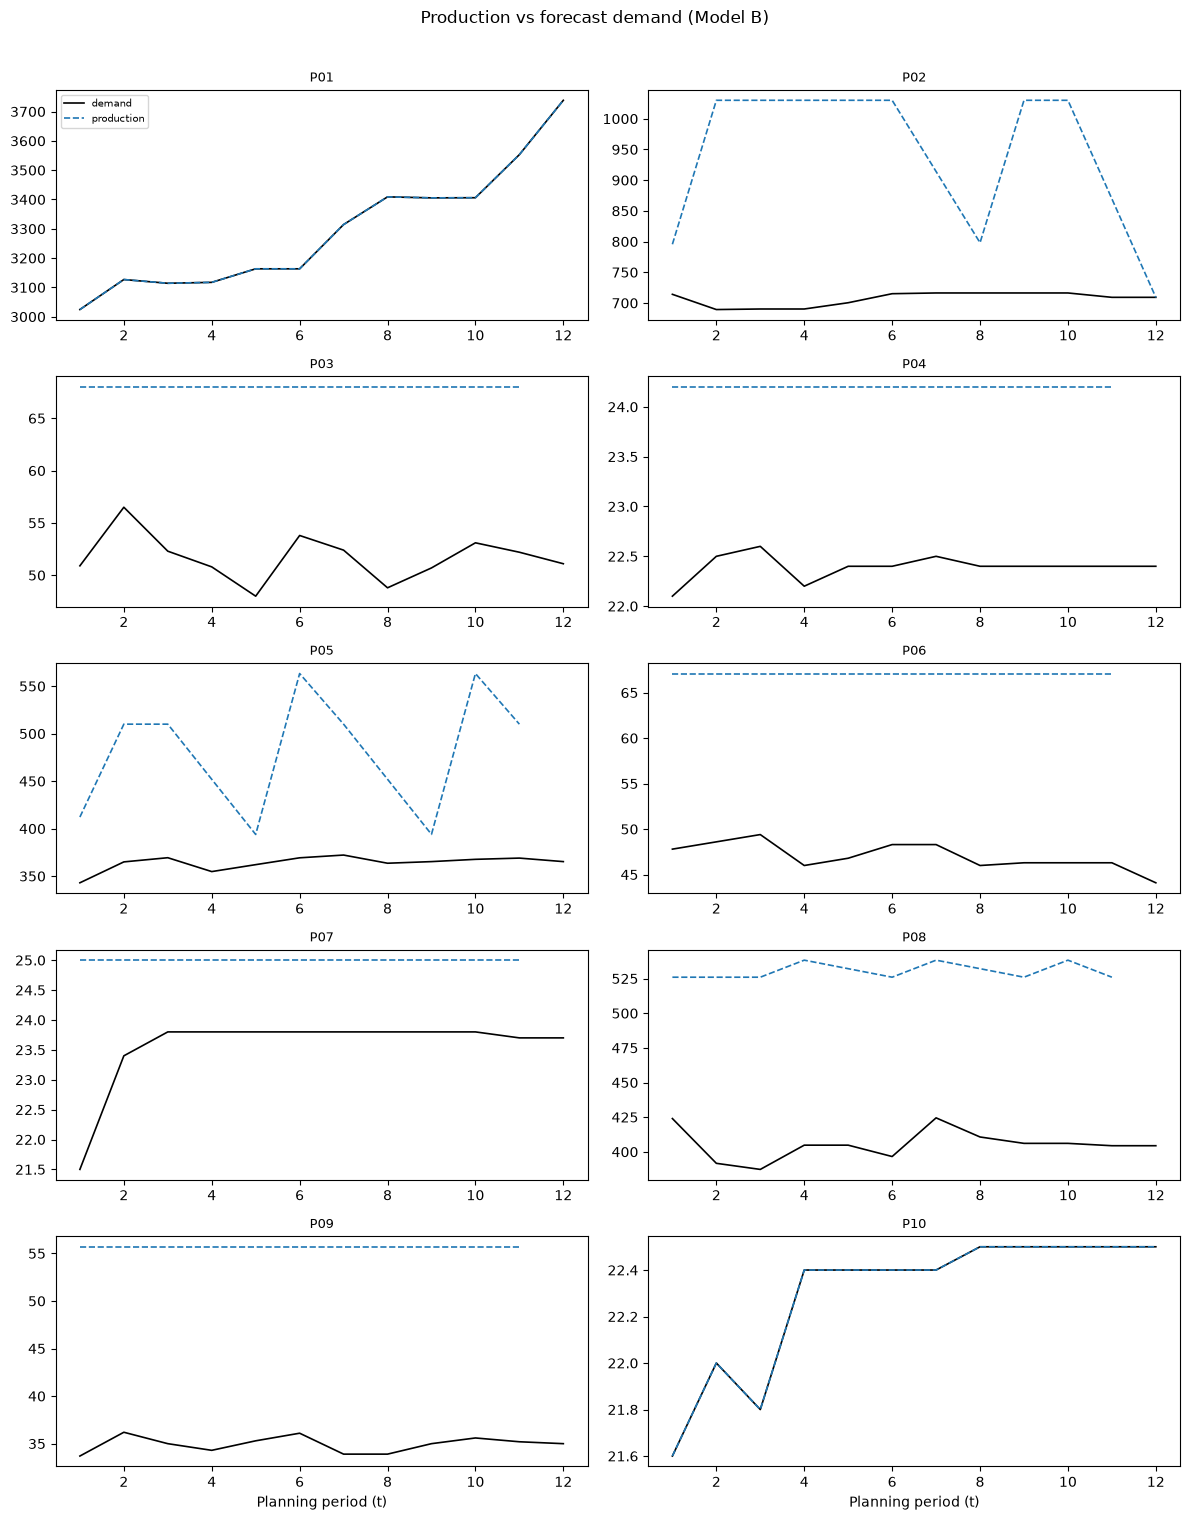

In [23]:
weekly_production = production_plan.groupby(["product_id", "t"])["quantity"].sum().reset_index()

fig, axes = plt.subplots(5, 2, figsize=(12, 15), sharex=False)

for ax, p in zip(axes.flat, P):
    dem = forecast[forecast["product_id"] == p].sort_values("t")
    prod = weekly_production[weekly_production["product_id"] == p]

    ax.plot(dem["t"], dem["forecast"], color="black", linewidth=1.2, label="demand")
    ax.plot(prod["t"], prod["quantity"], color="tab:blue", linestyle="--", linewidth=1.2, label="production")
    ax.set_title(p, fontsize=9)

axes.flat[0].legend(fontsize=7)
for ax in axes[-1]:
    ax.set_xlabel("Planning period (t)")

fig.suptitle("Production vs forecast demand (Model B)", y=1.01)
fig.tight_layout()
plt.show()

## Visualization: inventory trajectory, per product

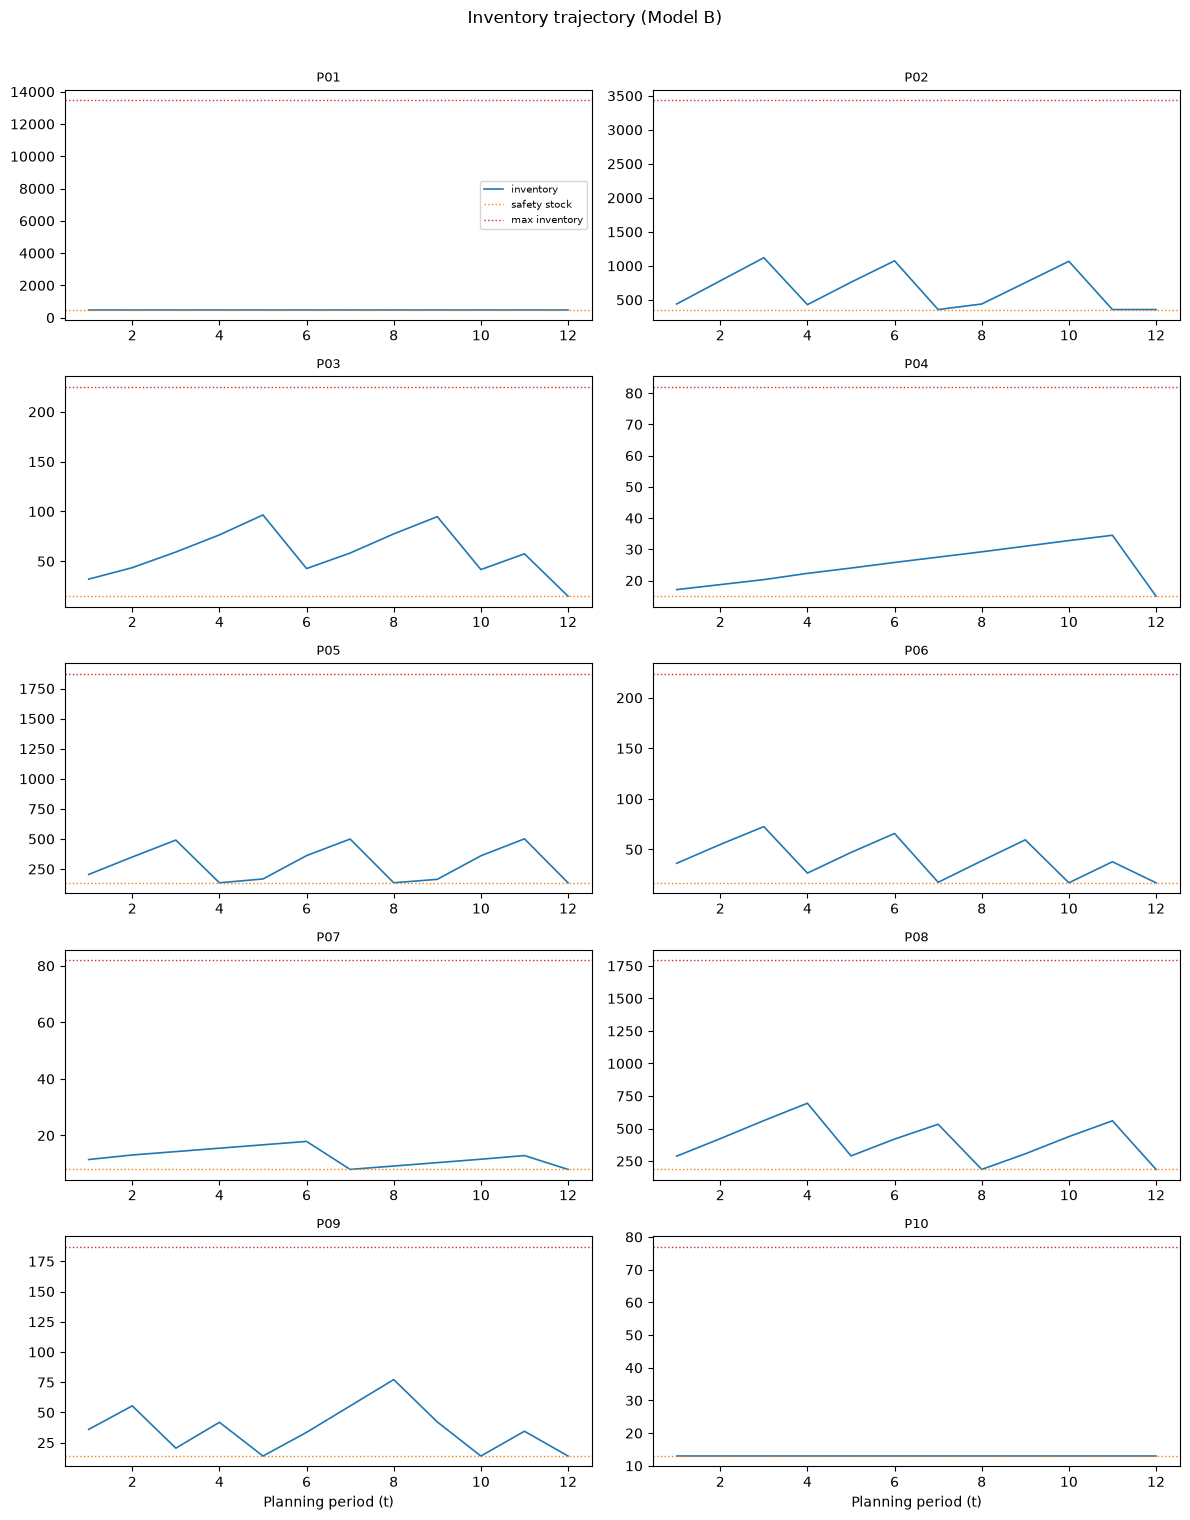

In [24]:
fig, axes = plt.subplots(5, 2, figsize=(12, 15), sharex=False)

for ax, p in zip(axes.flat, P):
    inv = inventory_plan[inventory_plan["product_id"] == p].sort_values("t")

    ax.plot(inv["t"], inv["inventory"], color="tab:blue", linewidth=1.2, label="inventory")
    ax.axhline(safety_stock[p], color="tab:orange", linestyle=":", linewidth=1, label="safety stock")
    ax.axhline(max_inventory[p], color="tab:red", linestyle=":", linewidth=1, label="max inventory")
    ax.set_title(p, fontsize=9)

axes.flat[0].legend(fontsize=7)
for ax in axes[-1]:
    ax.set_xlabel("Planning period (t)")

fig.suptitle("Inventory trajectory (Model B)", y=1.01)
fig.tight_layout()
plt.show()

## Visualization: machine utilization (Model B)

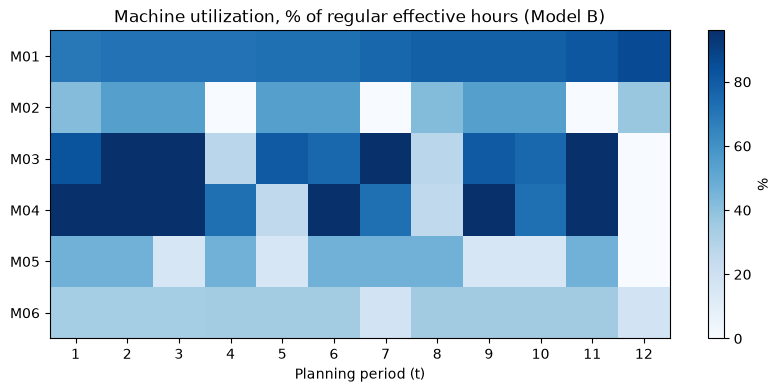

t,1,2,3,4,5,6,7,8,9,10,11,12
machine_id,,,,,,,,,,,,
M01,69.3,71.6,71.3,71.4,72.5,72.5,75.9,78.1,78.0,78.0,81.4,85.6
M02,41.9,54.2,54.2,0.0,54.2,54.2,0.0,42.0,54.2,54.2,0.0,37.3
M03,82.8,96.0,96.0,27.4,80.4,75.7,96.0,27.4,80.4,75.7,96.0,0.0
M04,96.0,96.0,96.0,72.4,25.3,96.0,72.4,25.3,96.0,72.4,96.0,0.0
M05,46.3,46.3,15.4,46.3,15.4,46.3,46.3,46.3,15.4,15.4,46.3,0.0
M06,33.8,34.1,34.0,34.4,34.4,34.4,17.8,34.5,34.5,34.5,34.5,17.9


In [25]:
production_plan["hours"] = production_plan.apply(
    lambda r: processing_time[(r["product_id"], r["machine_id"])] * r["quantity"], axis=1
)
used_hours = production_plan.groupby(["machine_id", "t"])["hours"].sum().reset_index()

util = pd.DataFrame([(m, t) for m in M for t in T], columns=["machine_id", "t"])
util = util.merge(used_hours, on=["machine_id", "t"], how="left").fillna({"hours": 0})
util["available_hours"] = util.apply(lambda r: available_hours[(r["machine_id"], r["t"])], axis=1)
util["utilization_pct"] = (util["hours"] / util["available_hours"] * 100).round(1)

pivot_util = util.pivot(index="machine_id", columns="t", values="utilization_pct").reindex(M)

fig, ax = plt.subplots(figsize=(10, 4))
im = ax.imshow(pivot_util.values, aspect="auto", cmap="Blues", vmin=0)
ax.set_yticks(range(len(pivot_util.index)))
ax.set_yticklabels(pivot_util.index)
ax.set_xticks(range(len(pivot_util.columns)))
ax.set_xticklabels(pivot_util.columns)
ax.set_xlabel("Planning period (t)")
ax.set_title("Machine utilization, % of regular effective hours (Model B)")
fig.colorbar(im, ax=ax, label="%")
plt.show()

pivot_util

## Visualization: setup count per machine per week

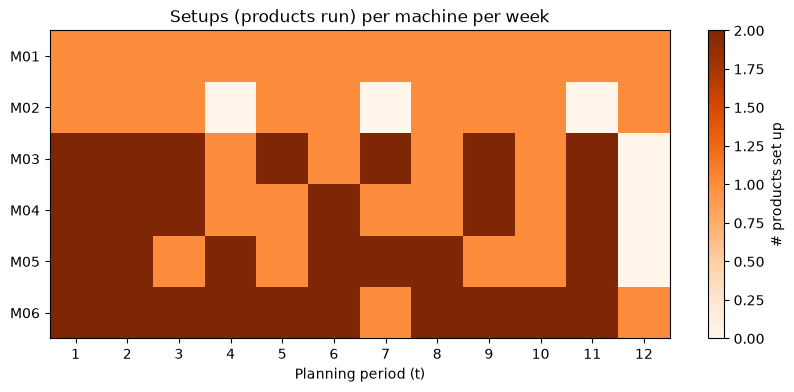

t,1,2,3,4,5,6,7,8,9,10,11,12
machine_id,,,,,,,,,,,,
M01,1,1,1,1,1,1,1,1,1,1,1,1
M02,1,1,1,0,1,1,0,1,1,1,0,1
M03,2,2,2,1,2,1,2,1,2,1,2,0
M04,2,2,2,1,1,2,1,1,2,1,2,0
M05,2,2,1,2,1,2,2,2,1,1,2,0
M06,2,2,2,2,2,2,1,2,2,2,2,1


In [26]:
setup_report["count"] = 1
setup_pivot = setup_report.pivot_table(index="machine_id", columns="t", values="count", aggfunc="sum", fill_value=0)
setup_pivot = setup_pivot.reindex(M, fill_value=0)

fig, ax = plt.subplots(figsize=(10, 4))
im = ax.imshow(setup_pivot.values, aspect="auto", cmap="Oranges", vmin=0)
ax.set_yticks(range(len(setup_pivot.index)))
ax.set_yticklabels(setup_pivot.index)
ax.set_xticks(range(len(setup_pivot.columns)))
ax.set_xticklabels(setup_pivot.columns)
ax.set_xlabel("Planning period (t)")
ax.set_title("Setups (products run) per machine per week")
fig.colorbar(im, ax=ax, label="# products set up")
plt.show()

setup_pivot